In [1]:
from google.colab import files

# Esto abrirá el selector de archivos
uploaded = files.upload()

# Una vez cargado, puedes verificar el nombre del archivo
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving MIAMI.csv to MIAMI.csv
User uploaded file "MIAMI.csv" with length 5450 bytes


In [3]:
import pandas as pd
import numpy as np

# 1. Cargar los datos
#df = pd.read_csv('TAMPICO.csv')
#df = pd.read_csv('HOUSTON.csv')
df = pd.read_csv('MIAMI.csv')
#df = pd.read_csv('MATAMOROS.csv')

series = df['temperature'].values  # Obtenemos el vector 1D

# 2. Definir los puntos de corte exactos (N=324)
# Entrenamiento (70%): 227 datos
# Validación (20%):    65 datos
# Prueba (10%):        32 datos
n_train = 227
n_val = 65
n_test = 32

# 3. Creación de los conjuntos 1D
# Para estos modelos, a veces el conjunto de 'entrenamiento'
# para el pronóstico final es la unión de (Train + Val)
train = series[:n_train]
val = series[n_train:n_train + n_val]
test = series[n_train + n_val:]

# 4. Verificación de integridad para tu manuscrito
print(f"--- Partición de Datos (1D) ---")
print(f"Total datos:        {len(series)}")
print(f"Train (0 a 226):    {len(train)} meses")
print(f"Val   (227 a 291):  {len(val)} meses")
print(f"Test  (292 a 323):  {len(test)} meses")

# Guardamos una referencia para el MASE (Error del modelo ingenuo en entrenamiento)
# Se calcula sobre el set de entrenamiento original
naive_mae_train = np.mean(np.abs(np.diff(train)))
print(f"Factor Naive MAE (para MASE): {naive_mae_train:.4f}")

--- Partición de Datos (1D) ---
Total datos:        324
Train (0 a 226):    227 meses
Val   (227 a 291):  65 meses
Test  (292 a 323):  32 meses
Factor Naive MAE (para MASE): 1.5894


In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calc_smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error (%)"""
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def calc_da(y_true, y_pred):
    """Directional Accuracy (%)"""
    # Compara si la dirección (subida/bajada) es la misma en ambos vectores
    y_true_diff = np.diff(y_true)
    y_pred_diff = np.diff(y_pred)
    return 100 * np.mean(np.sign(y_true_diff) == np.sign(y_pred_diff))

def calc_mase(y_true, y_pred, y_train):
    """Mean Absolute Scaled Error"""
    # Calcula el error del modelo ingenuo en el conjunto de entrenamiento
    n = len(y_train)
    d = np.abs(np.diff(y_train)).sum() / (n - 1)

    # Si d es 0 (serie constante), evitamos división por cero
    if d == 0: return np.nan

    mae_model = mean_absolute_error(y_true, y_pred)
    return mae_model / d

Iniciando búsqueda de hiperparámetros SSA (L y r) en Validación...

--- SINTONIZACIÓN COMPLETADA ---
Mejor Ventana (L): 36
Mejor Componente (r): 9
RMSE (Validación): 0.9311

Calculando pronóstico definitivo sobre el conjunto de PRUEBA...

=== RESULTADOS FINALES SSA (Conjunto Test) ===
RMSE:  0.8118
SMAPE: 2.62%
DA:    96.77%
MASE:  0.4130


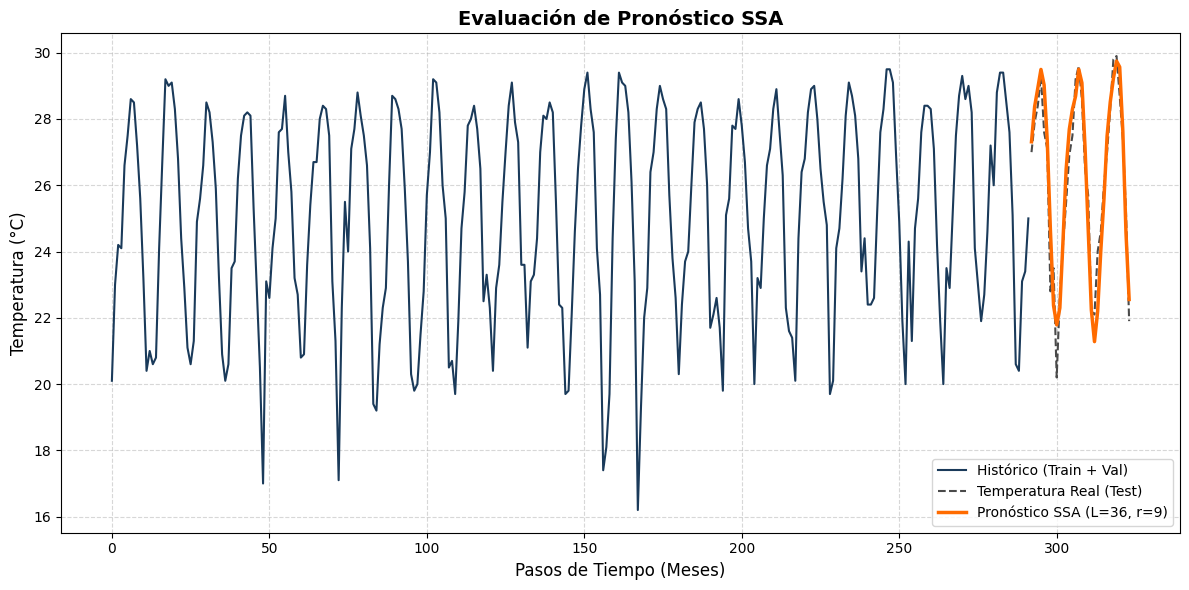


[ÉXITO] Archivos guardados: 'ssa_puro_test_forecast.png' y 'MIAMI-resultados_ssa_puro_test.csv'.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import svd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =====================================================================
# 1. FUNCIÓN SSA (Proporcionada por el Autor)
# =====================================================================
def ssa_lrr_forecast(series, L, r, n_forecast):
    """
    Pronóstico SSA usando Relaciones de Recurrencia Lineal (LRR).
    """
    N = len(series)
    # 1. Embedding: Crear la matriz de trayectoria
    K = N - L + 1
    X = np.column_stack([series[i:i+L] for i in range(K)])

    # 2. SVD: Descomposición en valores singulares
    U, s, Vh = svd(X)
    Ur = U[:, :r] # Tomamos solo los r componentes principales

    # 3. Obtener coeficientes de la Relación de Recurrencia Lineal (LRR)
    v2 = Ur[-1, :] # Última fila
    U_sub = Ur[:-1, :] # Todas las filas excepto la última

    # Coeficiente vertical de la proyección
    vertical_sq = np.sum(v2**2)
    if vertical_sq >= 1: # Evitar inestabilidad numérica
        return np.full(n_forecast, np.nan)

    # Vector de coeficientes R
    R = (1 / (1 - vertical_sq)) * np.dot(U_sub, v2)
    R = R[::-1] # Invertimos para la aplicación directa del producto punto

    # 4. Pronóstico iterativo
    forecast = list(series)
    for _ in range(n_forecast):
        # Tomamos los últimos L-1 datos para predecir el siguiente
        next_val = np.dot(R, forecast[-(L-1):])
        forecast.append(next_val)

    return np.array(forecast[N:])

# =====================================================================
# 2. FUNCIONES DE MÉTRICAS Q1
# =====================================================================
def calc_smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def calc_da(y_true, y_pred):
    y_true_diff = np.diff(y_true)
    y_pred_diff = np.diff(y_pred)
    if len(y_true_diff) == 0: return np.nan
    return 100 * np.mean(np.sign(y_true_diff) == np.sign(y_pred_diff))

def calc_mase(y_true, y_pred, y_train):
    n = len(y_train)
    d = np.abs(np.diff(y_train)).sum() / (n - 1)
    if d == 0: return np.nan
    mae_model = mean_absolute_error(y_true, y_pred)
    return mae_model / d

# =====================================================================
# FASE 1: SINTONIZACIÓN PURA (Búsqueda Exhaustiva de L y r en Validación)
# =====================================================================
n_train = len(train)
n_val = len(val)
best_rmse = float('inf')
best_L, best_r = 0, 0

print("Iniciando búsqueda de hiperparámetros SSA (L y r) en Validación...")

# L va desde la mitad de la serie hasta 12 (un ciclo anual)
for L in range(int(n_train/2), 12, -1):
    for r in range(L-1, 1, -1):

        preds_val = ssa_lrr_forecast(train, L, r, n_val)

        # Filtro de divergencia (inestabilidad numérica)
        if np.any(np.isnan(preds_val)) or np.max(np.abs(preds_val)) > 50:
            continue

        rmse_val = np.sqrt(mean_squared_error(val, preds_val))

        if rmse_val < best_rmse:
            best_rmse = rmse_val
            best_L = L
            best_r = r

print(f"\n--- SINTONIZACIÓN COMPLETADA ---")
print(f"Mejor Ventana (L): {best_L}")
print(f"Mejor Componente (r): {best_r}")
print(f"RMSE (Validación): {best_rmse:.4f}")

# =====================================================================
# FASE 2: EVALUACIÓN FINAL CÍEGA (Sobre conjunto de Prueba)
# =====================================================================
if best_L > 0:
    print("\nCalculando pronóstico definitivo sobre el conjunto de PRUEBA...")

    # Unimos Train y Val para darle al modelo toda la historia disponible antes del Test
    history = np.concatenate((train, val))
    n_test = len(test)

    # Pronóstico en el Test usando los hiperparámetros ganadores
    test_preds = ssa_lrr_forecast(history, best_L, best_r, n_test)

    # Cálculo de métricas finales
    final_rmse = np.sqrt(mean_squared_error(test, test_preds))
    final_smape = calc_smape(test, test_preds)
    final_da = calc_da(test, test_preds)
    final_mase = calc_mase(test, test_preds, history)

    print("\n=== RESULTADOS FINALES SSA (Conjunto Test) ===")
    print(f"RMSE:  {final_rmse:.4f}")
    print(f"SMAPE: {final_smape:.2f}%")
    print(f"DA:    {final_da:.2f}%")
    print(f"MASE:  {final_mase:.4f}")
    print("==============================================")

    # =====================================================================
    # FASE 3: EXPORTACIÓN Y GRÁFICA DE LA PRUEBA FINAL
    # =====================================================================
    plt.figure(figsize=(12, 6))

    time_history = np.arange(len(history))
    time_test = np.arange(len(history), len(history) + n_test)

    plt.plot(time_history, history, label='Histórico (Train + Val)', color='#1A3A5A', linewidth=1.5)
    plt.plot(time_test, test, label='Temperatura Real (Test)', color='#4A4A4A', linestyle='--', linewidth=1.5)
    plt.plot(time_test, test_preds, label=f'Pronóstico SSA (L={best_L}, r={best_r})', color='#FF6B00', linewidth=2.5)

    plt.title('Evaluación de Pronóstico SSA', fontsize=14, fontweight='bold')
    plt.xlabel('Pasos de Tiempo (Meses)', fontsize=12)
    plt.ylabel('Temperatura (°C)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    #plt.savefig('tampico-ssa_puro_test_forecast.png', dpi=300, bbox_inches='tight')
    #plt.savefig('HOUSTON-ssa_puro_test_forecast.png', dpi=300, bbox_inches='tight')
    plt.savefig('MIAMI-ssa_puro_test_forecast.png', dpi=300, bbox_inches='tight')
    #plt.savefig('MATAMOROS-ssa_puro_test_forecast.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Guardamos el CSV
    df_results = pd.DataFrame({
        'Paso_Tiempo': time_test,
        'Temp_Real_Test': test,
        'Pronostico_SSA': test_preds,
        'Error_Absoluto': np.abs(test - test_preds)
    })

    #csv_filename = 'TAMPICO-resultados_ssa_puro_test.csv'
    #csv_filename = 'HOUSTON-resultados_ssa_puro_test.csv'
    csv_filename = 'MIAMI-resultados_ssa_puro_test.csv'
    #csv_filename = 'MATAMOROS-resultados_ssa_puro_test.csv'
    df_results.to_csv(csv_filename, index=False)
    print(f"\n[ÉXITO] Archivos guardados: 'ssa_puro_test_forecast.png' y '{csv_filename}'.")

else:
    print("ERROR: El modelo divergió en todos los hiperparámetros de validación.")

Iniciando búsqueda exhaustiva para Holt-Winters...

--- PARÁMETROS ÓPTIMOS ENCONTRADOS (H&W) ---
Mejor Tendencia: 'mul'
Mejor Estacionalidad: 'add'
RMSE (Validación): 1.3106

Calculando pronóstico ciego sobre el conjunto de PRUEBA...

=== RESULTADOS FINALES H&W (Conjunto Test) ===
RMSE:  1.7158
SMAPE: 5.30%
DA:    83.87%
MASE:  0.5164


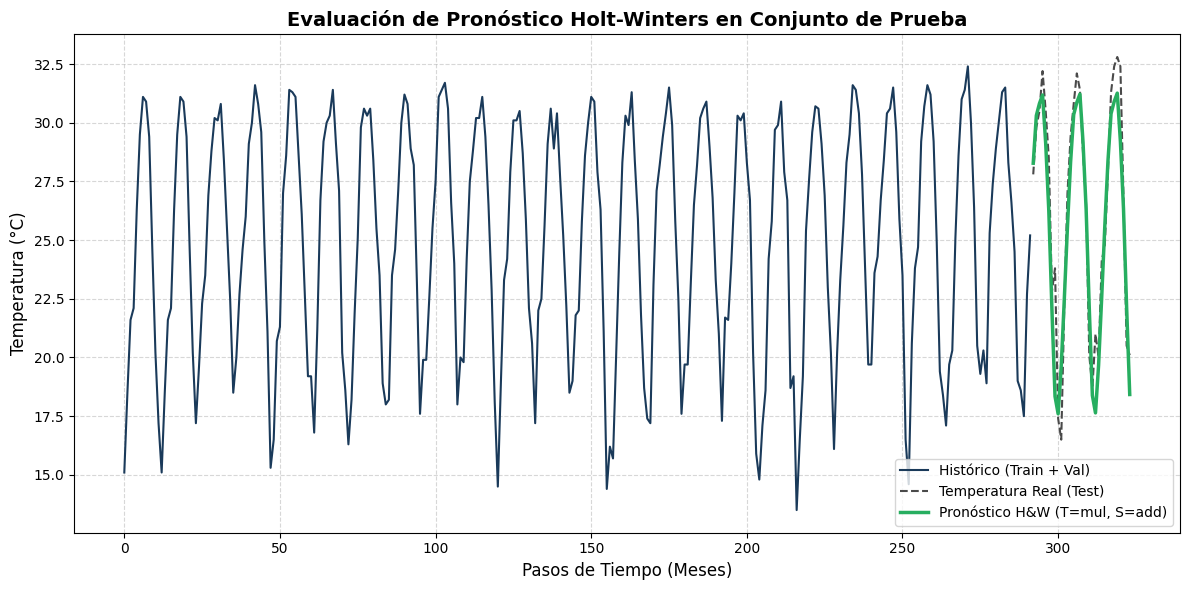


[ÉXITO] Archivos guardados: 'hw_test_forecast_madero.png' y 'resultados_hw_test_MATAMOROS.csv'.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

# Silenciamos las advertencias de convergencia que son normales durante el Grid Search
warnings.filterwarnings("ignore")

# =====================================================================
# FASE 1: SINTONIZACIÓN (Búsqueda Exhaustiva en Validación)
# =====================================================================
print("Iniciando búsqueda exhaustiva para Holt-Winters...")

# Definimos el espacio de búsqueda
tendencias = ['add', 'mul', None]
estacionalidades = ['add', 'mul']
periodo_estacional = 12 # 1 ciclo anual

best_rmse_hw = float('inf')
best_trend = None
best_seasonal = None

# Bucle Grid Search
for t, s in itertools.product(tendencias, estacionalidades):
    try:
        # Entrenamos con el conjunto Train
        modelo_hw = ExponentialSmoothing(
            train,
            trend=t,
            seasonal=s,
            seasonal_periods=periodo_estacional,
            initialization_method="estimated"
        ).fit()

        # Pronosticamos en el horizonte de Validación
        preds_val_hw = modelo_hw.forecast(len(val))

        # Si arroja NaNs, saltamos
        if np.any(np.isnan(preds_val_hw)):
            continue

        # Calculamos RMSE de validación
        rmse_val_hw = np.sqrt(mean_squared_error(val, preds_val_hw))

        # Guardamos el mejor modelo
        if rmse_val_hw < best_rmse_hw:
            best_rmse_hw = rmse_val_hw
            best_trend = t
            best_seasonal = s

    except Exception as e:
        # Algunos modelos multiplicativos fallan si hay ceros o negativos
        continue

print(f"\n--- PARÁMETROS ÓPTIMOS ENCONTRADOS (H&W) ---")
print(f"Mejor Tendencia: '{best_trend}'")
print(f"Mejor Estacionalidad: '{best_seasonal}'")
print(f"RMSE (Validación): {best_rmse_hw:.4f}")

# =====================================================================
# FASE 2: EVALUACIÓN FINAL (Sobre conjunto de Prueba / Test)
# =====================================================================
if best_seasonal is not None:
    print("\nCalculando pronóstico ciego sobre el conjunto de PRUEBA...")

    # 1. Unimos Train y Val (Historia completa)
    history = np.concatenate((train, val))
    n_test = len(test)

    # 2. Entrenamos el modelo definitivo con toda la historia y los mejores hiperparámetros
    modelo_final_hw = ExponentialSmoothing(
        history,
        trend=best_trend,
        seasonal=best_seasonal,
        seasonal_periods=periodo_estacional,
        initialization_method="estimated"
    ).fit()

    # 3. Pronosticamos el Test ciego
    test_preds_hw = modelo_final_hw.forecast(n_test)

    # 4. Calculamos las métricas Q1 sobre el Test
    final_rmse_hw = np.sqrt(mean_squared_error(test, test_preds_hw))
    final_smape_hw = calc_smape(test, test_preds_hw)
    final_da_hw = calc_da(test, test_preds_hw)
    final_mase_hw = calc_mase(test, test_preds_hw, history)

    print("\n=== RESULTADOS FINALES H&W (Conjunto Test) ===")
    print(f"RMSE:  {final_rmse_hw:.4f}")
    print(f"SMAPE: {final_smape_hw:.2f}%")
    print(f"DA:    {final_da_hw:.2f}%")
    print(f"MASE:  {final_mase_hw:.4f}")
    print("==============================================")

    # =====================================================================
    # FASE 3: EXPORTACIÓN Y GRÁFICA DE LA PRUEBA FINAL
    # =====================================================================
    plt.figure(figsize=(12, 6))

    time_history = np.arange(len(history))
    time_test = np.arange(len(history), len(history) + n_test)

    plt.plot(time_history, history, label='Histórico (Train + Val)', color='#1A3A5A', linewidth=1.5)
    plt.plot(time_test, test, label='Temperatura Real (Test)', color='#4A4A4A', linestyle='--', linewidth=1.5)
    plt.plot(time_test, test_preds_hw, label=f'Pronóstico H&W (T={best_trend}, S={best_seasonal})', color='#27AE60', linewidth=2.5)

    plt.title('Evaluación de Pronóstico Holt-Winters en Conjunto de Prueba', fontsize=14, fontweight='bold')
    plt.xlabel('Pasos de Tiempo (Meses)', fontsize=12)
    plt.ylabel('Temperatura (°C)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    #plt.savefig('hw_test_forecast_TAMPICO.png', dpi=300, bbox_inches='tight')
    #plt.savefig('hw_test_forecast_HOUSTON.png', dpi=300, bbox_inches='tight')
    #plt.savefig('hw_test_forecast_MIAMI.png', dpi=300, bbox_inches='tight')
    plt.savefig('hw_test_forecast_MATAMOROS.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Guardamos el CSV
    df_results_hw = pd.DataFrame({
        'Paso_Tiempo': time_test,
        'Temp_Real_Test': test,
        'Pronostico_HW': test_preds_hw,
        'Error_Absoluto': np.abs(test - test_preds_hw)
    })

    #csv_filename_hw = 'resultados_hw_test_tampico.csv'
    #csv_filename_hw = 'resultados_hw_test_HOUSTON.csv'
    #csv_filename_hw = 'resultados_hw_test_MIAMI.csv'
    csv_filename_hw = 'resultados_hw_test_MATAMOROS.csv'
    df_results_hw.to_csv(csv_filename_hw, index=False)
    print(f"\n[ÉXITO] Archivos guardados: 'hw_test_forecast_madero.png' y '{csv_filename_hw}'.")

else:
    print("ERROR: Holt-Winters no logró converger con ninguna combinación.")

Iniciando búsqueda exhaustiva optimizada para SARIMA...
Esto puede tomar un par de minutos dependiendo de su procesador...

--- PARÁMETROS ÓPTIMOS ENCONTRADOS (SARIMA) ---
Mejor Orden ARMA (p, d, q): (0, 1, 1)
Mejor Orden Estacional (P, D, Q, s): (1, 0, 1, 12)
RMSE (Validación): 1.3506

Calculando pronóstico ciego sobre el conjunto de PRUEBA...

=== RESULTADOS FINALES SARIMA (Conjunto Test) ===
RMSE:  1.7232
SMAPE: 5.30%
DA:    83.87%
MASE:  0.5189


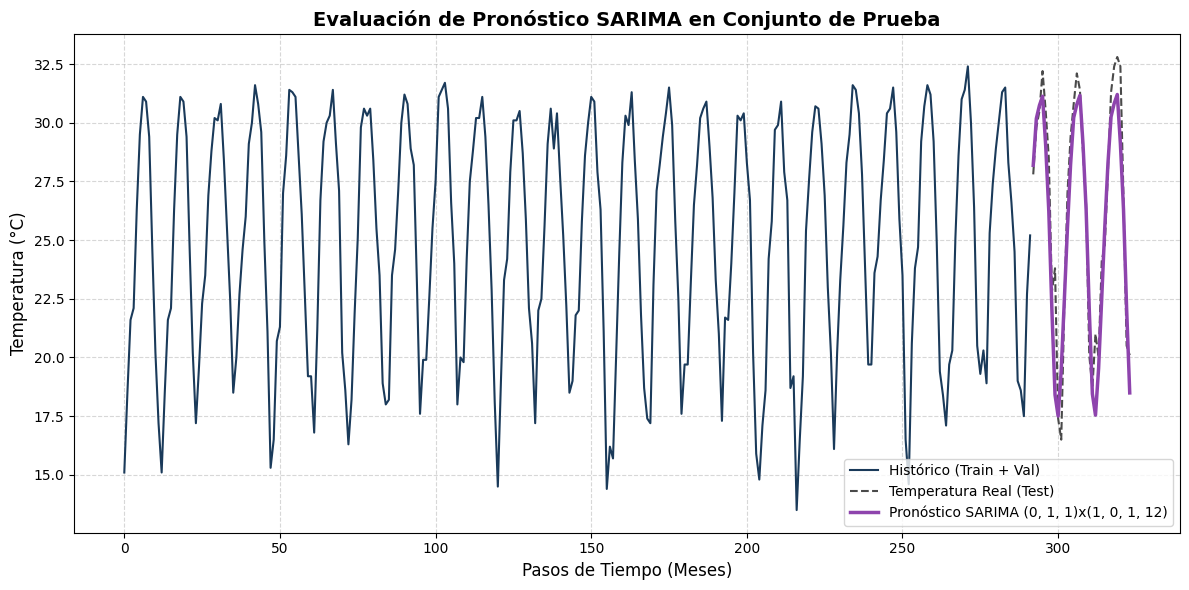


[ÉXITO] Archivos guardados: 'sarima_test_forecast_madero.png' y 'resultados_sarima_test_MATAMOROS.csv'.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# Silenciamos las advertencias de statsmodels (frecuentes por matrices no invertibles durante la búsqueda)
warnings.filterwarnings("ignore")

# =====================================================================
# FASE 1: SINTONIZACIÓN (Búsqueda Exhaustiva en Validación)
# =====================================================================
print("Iniciando búsqueda exhaustiva optimizada para SARIMA...")
print("Esto puede tomar un par de minutos dependiendo de su procesador...\n")

# Definimos el espacio de búsqueda (0 y 1 son suficientes para evitar sobreajuste en clima)
p = d = q = range(0, 2)
P = D = Q = range(0, 2)
s = 12 # Periodo estacional anual

# Generamos todas las combinaciones posibles
pdq_combinations = list(itertools.product(p, d, q))
seasonal_combinations = list(itertools.product(P, D, Q))

best_rmse_sarima = float('inf')
best_pdq = None
best_seasonal = None

# Bucle Grid Search
for param in pdq_combinations:
    for param_seasonal in seasonal_combinations:
        try:
            # Construimos el seasonal_order completo agregando 's'
            spdq = (param_seasonal[0], param_seasonal[1], param_seasonal[2], s)

            # Entrenamos con el conjunto Train
            # Usamos enforce_stationarity=False para agilizar la búsqueda de malla
            modelo_sarima = SARIMAX(
                train,
                order=param,
                seasonal_order=spdq,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            resultados_fit = modelo_sarima.fit(disp=False)

            # Pronosticamos en el horizonte de Validación
            preds_val_sarima = resultados_fit.forecast(steps=len(val))

            # Si el modelo explota y da NaNs, lo descartamos
            if np.any(np.isnan(preds_val_sarima)):
                continue

            # Calculamos RMSE de validación
            rmse_val_sarima = np.sqrt(mean_squared_error(val, preds_val_sarima))

            # Guardamos el mejor modelo
            if rmse_val_sarima < best_rmse_sarima:
                best_rmse_sarima = rmse_val_sarima
                best_pdq = param
                best_seasonal = spdq

        except Exception as e:
            # SARIMA tira muchos errores de álgebra lineal (ej. LU decomposition) con malos parámetros
            continue

print(f"--- PARÁMETROS ÓPTIMOS ENCONTRADOS (SARIMA) ---")
print(f"Mejor Orden ARMA (p, d, q): {best_pdq}")
print(f"Mejor Orden Estacional (P, D, Q, s): {best_seasonal}")
print(f"RMSE (Validación): {best_rmse_sarima:.4f}")

# =====================================================================
# FASE 2: EVALUACIÓN FINAL (Sobre conjunto de Prueba / Test)
# =====================================================================
if best_pdq is not None:
    print("\nCalculando pronóstico ciego sobre el conjunto de PRUEBA...")

    # 1. Unimos Train y Val (Historia completa)
    history = np.concatenate((train, val))
    n_test = len(test)

    # 2. Entrenamos el modelo DEFINITIVO con toda la historia y los mejores hiperparámetros
    # Aquí sí forzamos la estacionariedad para el modelo final riguroso
    modelo_final_sarima = SARIMAX(
        history,
        order=best_pdq,
        seasonal_order=best_seasonal,
        enforce_stationarity=True,
        enforce_invertibility=True
    ).fit(disp=False)

    # 3. Pronosticamos el Test ciego
    test_preds_sarima = modelo_final_sarima.forecast(steps=n_test)

    # 4. Calculamos las métricas Q1 sobre el Test
    final_rmse_sarima = np.sqrt(mean_squared_error(test, test_preds_sarima))
    final_smape_sarima = calc_smape(test, test_preds_sarima)
    final_da_sarima = calc_da(test, test_preds_sarima)
    final_mase_sarima = calc_mase(test, test_preds_sarima, history)

    print("\n=== RESULTADOS FINALES SARIMA (Conjunto Test) ===")
    print(f"RMSE:  {final_rmse_sarima:.4f}")
    print(f"SMAPE: {final_smape_sarima:.2f}%")
    print(f"DA:    {final_da_sarima:.2f}%")
    print(f"MASE:  {final_mase_sarima:.4f}")
    print("=================================================")

    # =====================================================================
    # FASE 3: EXPORTACIÓN Y GRÁFICA DE LA PRUEBA FINAL
    # =====================================================================
    plt.figure(figsize=(12, 6))

    time_history = np.arange(len(history))
    time_test = np.arange(len(history), len(history) + n_test)

    plt.plot(time_history, history, label='Histórico (Train + Val)', color='#1A3A5A', linewidth=1.5)
    plt.plot(time_test, test, label='Temperatura Real (Test)', color='#4A4A4A', linestyle='--', linewidth=1.5)

    # Línea morada para SARIMA
    plt.plot(time_test, test_preds_sarima, label=f'Pronóstico SARIMA {best_pdq}x{best_seasonal}', color='#8E44AD', linewidth=2.5)

    plt.title('Evaluación de Pronóstico SARIMA en Conjunto de Prueba', fontsize=14, fontweight='bold')
    plt.xlabel('Pasos de Tiempo (Meses)', fontsize=12)
    plt.ylabel('Temperatura (°C)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    #plt.savefig('sarima_test_forecast_TAMPICO.png', dpi=300, bbox_inches='tight')
    #plt.savefig('sarima_test_forecast_HOUSTON.png', dpi=300, bbox_inches='tight')
    #plt.savefig('sarima_test_forecast_MIAMI.png', dpi=300, bbox_inches='tight')
    plt.savefig('sarima_test_forecast_MATAMOROS.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Guardamos el CSV
    df_results_sarima = pd.DataFrame({
        'Paso_Tiempo': time_test,
        'Temp_Real_Test': test,
        'Pronostico_SARIMA': test_preds_sarima,
        'Error_Absoluto': np.abs(test - test_preds_sarima)
    })

    #csv_filename_sarima = 'resultados_sarima_test_tampico.csv'
    #csv_filename_sarima = 'resultados_sarima_test_HOUSTON.csv'
    #csv_filename_sarima = 'resultados_sarima_test_MIAMI.csv'
    csv_filename_sarima = 'resultados_sarima_test_MATAMOROS.csv'
    df_results_sarima.to_csv(csv_filename_sarima, index=False)
    print(f"\n[ÉXITO] Archivos guardados: 'sarima_test_forecast_madero.png' y '{csv_filename_sarima}'.")

else:
    print("ERROR: SARIMA no logró converger con ninguna combinación.")